### Importing and Understanding Data

In [2]:
import pandas as pd
import numpy as np

In [3]:
# Importing Housing.csv
housing = pd.read_csv("newhousing.csv")

In [4]:
# Looking at the first five rows
housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished,areaperbedroom,bbratio
0,5250000,5500,3,2,1,1,0,1,0,0,0,0,1,0,1833.333333,0.666667
1,4480000,4040,3,1,2,1,0,0,0,0,1,0,1,0,1346.666667,0.333333
2,3570000,3640,2,1,1,1,0,0,0,0,0,0,0,1,1820.000000,0.500000
3,2870000,3040,2,1,1,0,0,0,0,0,0,0,0,1,1520.000000,0.500000
4,3570000,4500,2,1,1,0,0,0,0,0,0,0,0,0,2250.000000,0.500000


In [5]:
housing.shape

(545, 16)

In [6]:
# What type of values are stored in the columns?
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   price            545 non-null    int64  
 1   area             545 non-null    int64  
 2   bedrooms         545 non-null    int64  
 3   bathrooms        545 non-null    int64  
 4   stories          545 non-null    int64  
 5   mainroad         545 non-null    int64  
 6   guestroom        545 non-null    int64  
 7   basement         545 non-null    int64  
 8   hotwaterheating  545 non-null    int64  
 9   airconditioning  545 non-null    int64  
 10  parking          545 non-null    int64  
 11  prefarea         545 non-null    int64  
 12  semi-furnished   545 non-null    int64  
 13  unfurnished      545 non-null    int64  
 14  areaperbedroom   545 non-null    float64
 15  bbratio          545 non-null    float64
dtypes: float64(2), int64(14)
memory usage: 68.3 KB


z## Splitting Data into Training and Testing Sets

In [7]:
housing.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'semi-furnished', 'unfurnished',
       'areaperbedroom', 'bbratio'],
      dtype='object')

In [8]:
# Putting feature variable to X
X = housing[
    [
        "area",
        "bedrooms",
        "bathrooms",
        "stories",
        "mainroad",
        "guestroom",
        "basement",
        "hotwaterheating",
        "airconditioning",
        "parking",
        "prefarea",
        "semi-furnished",
        "unfurnished",
        "areaperbedroom",
        "bbratio",
    ]
]

# Putting response variable to y
y = housing["price"]

<Axes: >

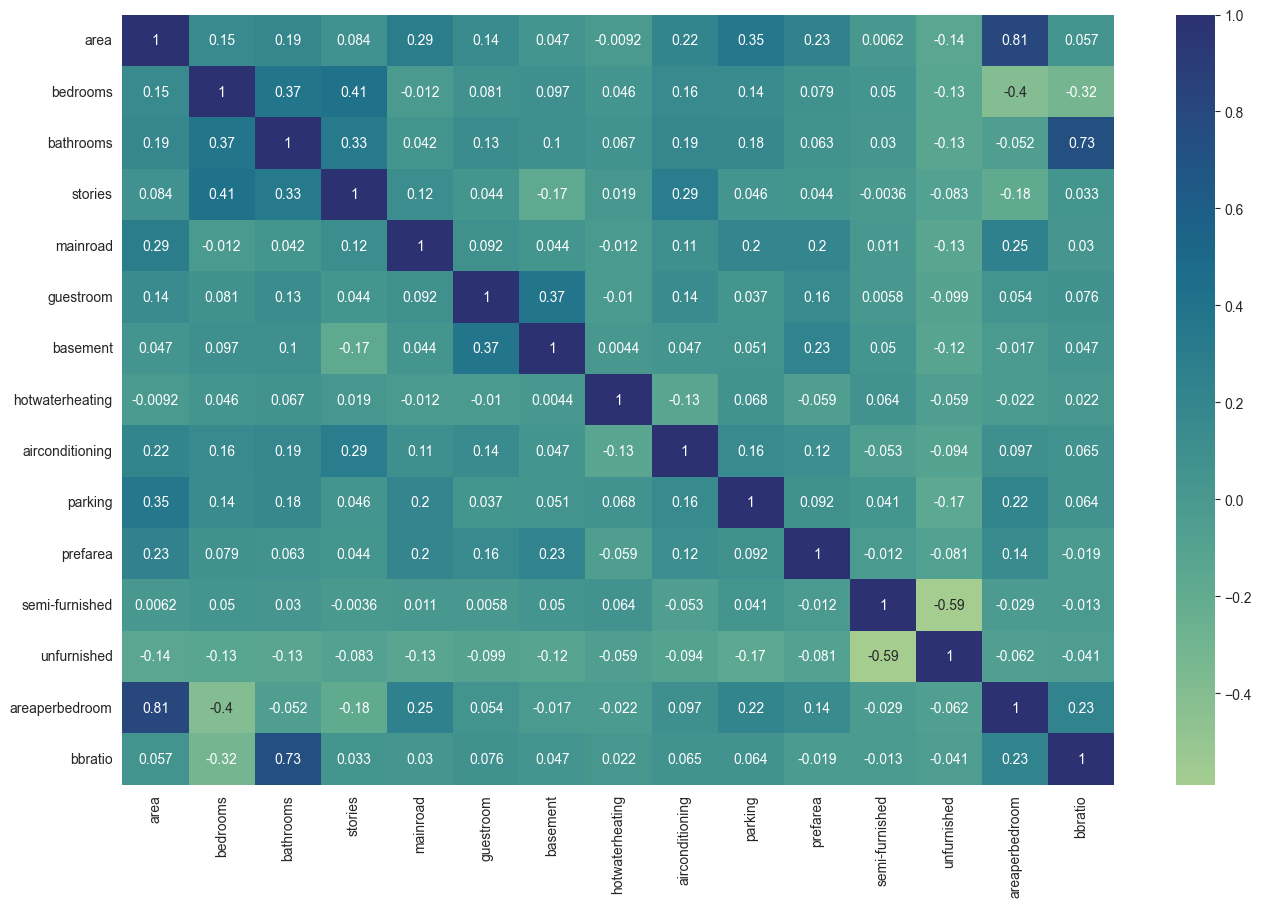

In [9]:
# Importing matplotlib and seaborn
import matplotlib.pyplot as plt
import seaborn as sns

# Let's see the correlation matrix
plt.figure(figsize=(16, 10))  # Size of the figure
sns.heatmap(X.corr(), annot=True, cmap="crest")

In [48]:
X[
    [
        "area",
        "bedrooms",
        "bathrooms",
        "stories",
        "mainroad",
        "guestroom",
        "basement",
        "hotwaterheating",
        "airconditioning",
        "parking",
        "prefarea",
        "semi-furnished",
        "unfurnished",
        "areaperbedroom",
        "bbratio",
    ]
].corr()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished,areaperbedroom,bbratio
area,1.000000,0.151858,0.193820,0.083996,0.288874,0.140297,0.047417,-0.009229,0.222393,0.352980,0.234779,0.006156,-0.142278,0.805610,0.057116
bedrooms,0.151858,1.000000,0.373930,0.408564,-0.012033,0.080549,0.097312,0.046049,0.160603,0.139270,0.079023,0.050040,-0.126252,-0.397259,-0.317303
bathrooms,0.193820,0.373930,1.000000,0.326165,0.042398,0.126469,0.102106,0.067159,0.186915,0.177496,0.063472,0.029834,-0.132107,-0.052352,0.727154
stories,0.083996,0.408564,0.326165,1.000000,0.121706,0.043538,-0.172394,0.018847,0.293602,0.045547,0.044425,-0.003648,-0.082972,-0.178942,0.032962
mainroad,0.288874,-0.012033,0.042398,0.121706,1.000000,0.092337,0.044002,-0.011781,0.105423,0.204433,0.199876,0.011450,-0.133123,0.249829,0.030407
guestroom,0.140297,0.080549,0.126469,0.043538,0.092337,1.000000,0.372066,-0.010308,0.138179,0.037466,0.160897,0.005821,-0.099023,0.054312,0.075854
basement,0.047417,0.097312,0.102106,-0.172394,0.044002,0.372066,1.000000,0.004385,0.047341,0.051497,0.228083,0.050284,-0.117935,-0.017034,0.047346
hotwaterheating,-0.009229,0.046049,0.067159,0.018847,-0.011781,-0.010308,0.004385,1.000000,-0.130023,0.067864,-0.059411,0.063819,-0.059194,-0.021634,0.021520
airconditioning,0.222393,0.160603,0.186915,0.293602,0.105423,0.138179,0.047341,-0.130023,1.000000,0.159173,0.117382,-0.053179,-0.094086,0.096830,0.064649
parking,0.352980,0.139270,0.177496,0.045547,0.204433,0.037466,0.051497,0.067864,0.159173,1.000000,0.091627,0.041327,-0.165705,0.224387,0.064107


In [10]:
# creating correlation matrix for the given data
corrmat = np.corrcoef(X.transpose())

In [11]:
corrmat.shape

(15, 15)

In [12]:
# Make a diagonal matrix with diagonal entry of Matrix corrmat
p = np.diagflat(corrmat.diagonal())

In [13]:
# subtract diagonal entries making all diagonals 0
corrmat_diag_zero = corrmat - p
print(
    "max corr:",
    corrmat_diag_zero.max(),
    ", min corr: ",
    corrmat_diag_zero.min(),
)

max corr: 0.8056104195904638 , min corr:  -0.5884049771343839


In [26]:
corrmat_diag_zero[13][0]

np.float64(0.8056104195904636)

### Question No. 1 and 2

In [15]:
# Retrieve the (i,j) index for which matrix has maximum value

ij_max = np.unravel_index(corrmat_diag_zero.argmax(), corrmat_diag_zero.shape)
print("ij_max is", ij_max)
print("Maximum correlation :", corrmat_diag_zero[ij_max])

ij_max is (np.int64(0), np.int64(13))
Maximum correlation : 0.8056104195904638


In [49]:
corrmat_diag_zero

array([[ 0.        ,  0.15185849,  0.19381953,  0.08399605,  0.28887411,
         0.14029659,  0.04741699, -0.00922924,  0.2223931 ,  0.35298048,
         0.2347788 ,  0.00615616, -0.14227821,  0.80561042,  0.0571156 ],
       [ 0.15185849,  0.        ,  0.37393024,  0.40856424, -0.01203324,
         0.0805487 ,  0.09731242,  0.04604889,  0.16060326,  0.1392699 ,
         0.07902306,  0.05003995, -0.12625202, -0.39725852, -0.31730317],
       [ 0.19381953,  0.37393024,  0.        ,  0.32616471,  0.04239762,
         0.12646884,  0.10210571,  0.0671591 ,  0.18691503,  0.17749582,
         0.06347174,  0.02983353, -0.13210748, -0.0523518 ,  0.72715441],
       [ 0.08399605,  0.40856424,  0.32616471,  0.        ,  0.12170613,
         0.04353767, -0.17239362,  0.01884651,  0.293602  ,  0.04554709,
         0.04442487, -0.0036483 , -0.08297194, -0.17894208,  0.0329617 ],
       [ 0.28887411, -0.01203324,  0.04239762,  0.12170613,  0.        ,
         0.09233692,  0.04400208, -0.01178149, 

In [16]:
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import explained_variance_score

# Importing the PCA module
from sklearn.decomposition import PCA

In [17]:
# random_state is the seed used by the random number generator, it can be any integer.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, test_size=0.3, random_state=100
)

from sklearn import preprocessing

X_scaler = preprocessing.StandardScaler().fit(X_train)
y_scaler = preprocessing.StandardScaler().fit(y_train.values.reshape(-1, 1))
Xtrain = X_scaler.transform(X_train)
ytrain = y_scaler.transform(y_train.values.reshape(-1, 1))

Xtest = X_scaler.transform(X_test)
ytest = y_scaler.transform(y_test.values.reshape(-1, 1))

In [42]:
# random_state is the seed used by the random number generator, it can be any integer.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, test_size=0.3, random_state=100
)

from sklearn import preprocessing

X_scaler = preprocessing.StandardScaler().fit(X_train)
y_scaler = preprocessing.StandardScaler().fit(y_train.values.reshape(-1, 1))
Xtrain = X_scaler.transform(X_train)
ytrain = y_scaler.transform(y_train.values.reshape(-1, 1))

Xtest = X_scaler.transform(X_test)
ytest = y_scaler.transform(y_test.values.reshape(-1, 1))

['__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_build_request_for_signature',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_params_html',
 '_html_repr',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_reset',
 '_sklearn_auto_wrap_output_keys',
 '_validate_params',
 'copy',
 'feature_names_in_',
 'fit',
 'fit_transform',
 'get_feature_names_out',
 'get_metadata_routing',
 'get_params',
 'inverse_transform

In [44]:
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7 ,test_size = 0.3, random_state=100)
#
# from sklearn import preprocessing
# scaler = preprocessing.StandardScaler()
# X_scaler = scaler.fit(X_train)
# y_scaler = scaler.fit(y_train.values.reshape(-1,1))
# Xtrain=X_scaler.transform(X_train)
# ytrain=y_scaler.transform(y_train.values.reshape(-1,1))
#
# Xtest=X_scaler.transform(X_test)
# ytest=y_scaler.transform(y_test.values.reshape(-1,1))

In [36]:
y_scaler

['with_mean',
 'with_std',
 'copy',
 'n_features_in_',
 'n_samples_seen_',
 'mean_',
 'var_',
 'scale_',
 '__module__',
 '__annotations__',
 '__doc__',
 '_parameter_constraints',
 '__init__',
 '_reset',
 'fit',
 'partial_fit',
 'transform',
 'inverse_transform',
 '__sklearn_tags__',
 'set_fit_request',
 'set_partial_fit_request',
 'set_transform_request',
 'set_inverse_transform_request',
 '_sklearn_auto_wrap_output_keys',
 'get_feature_names_out',
 '__dict__',
 '__weakref__',
 '__new__',
 '__repr__',
 '__hash__',
 '__str__',
 '__getattribute__',
 '__setattr__',
 '__delattr__',
 '__lt__',
 '__le__',
 '__eq__',
 '__ne__',
 '__gt__',
 '__ge__',
 '__reduce_ex__',
 '__reduce__',
 '__getstate__',
 '__subclasshook__',
 '__init_subclass__',
 '__format__',
 '__sizeof__',
 '__dir__',
 '__class__',
 'fit_transform',
 'set_output',
 '_html_repr',
 '_get_param_names',
 'get_params',
 '_get_params_html',
 'set_params',
 '__sklearn_clone__',
 '__setstate__',
 '_validate_params',
 '_repr_html_',
 '_r

### Question No. 4

In [45]:
pca = PCA(n_components=6, random_state=100)
pca2 = PCA(n_components=6, random_state=100)

# Scale and transform data to get Principal Components

# add code for question no. 4
# fit_transform and transform to get the reduced data
Xtrain_reduced = pca.fit_transform(X_train)
Xtest_reduced = pca.transform(X_test)


regrpca = linear_model.LinearRegression()
# Train the model using the principal components of the transformed training sets
regrpca.fit(Xtrain_reduced, ytrain)
# Make predictions using the principal components of the transformed testing set
y_pred = regrpca.predict(Xtest_reduced)
print("Mean squared error: %.2f" % mean_squared_error(ytest, y_pred))
# Explained variance score: 1 is perfect prediction
print("R2 score: %.2f" % r2_score(ytest, y_pred))

Mean squared error: 0.35
R2 score: 0.65


In [32]:
pca = PCA(n_components=6, random_state=100)
pca2 = PCA(n_components=6, random_state=100)

# Scale and transform data to get Principal Components

# add code for question no. 4
# fit_transform and transform to get the reduced data
Xtrain_reduced = pca.fit_transform(Xtrain)
Xtest_reduced = pca.transform(Xtest)


regrpca = linear_model.LinearRegression()
# Train the model using the principal components of the transformed training sets
regrpca.fit(Xtrain_reduced, ytrain)
# Make predictions using the principal components of the transformed testing set
y_pred = regrpca.predict(Xtest_reduced)
print("Mean squared error: %.2f" % mean_squared_error(ytest, y_pred))
# Explained variance score: 1 is perfect prediction
print("R2 score: %.2f" % r2_score(ytest, y_pred))

Mean squared error: 0.33
R2 score: 0.66


In [30]:
pca = PCA(n_components=6, random_state=100)
pca2 = PCA(n_components=6, random_state=100)

# Scale and transform data to get Principal Components

# add code for question no. 4
# fit_transform and transform to get the reduced data
Xtrain_reduced = pca.fit_transform(X_train)
Xtest_reduced = pca.transform(X_test)


regrpca = linear_model.LinearRegression()
# Train the model using the principal components of the transformed training sets
regrpca.fit(Xtrain_reduced, ytrain)
# Make predictions using the principal components of the transformed testing set
y_pred = regrpca.predict(Xtest_reduced)
print("Mean squared error: %.2f" % mean_squared_error(ytest, y_pred))
# Explained variance score: 1 is perfect prediction
print("R2 score: %.2f" % r2_score(ytest, y_pred))

Mean squared error: 0.35
R2 score: 0.65


In [20]:
df = pd.read_clipboard()

In [21]:
df

,%matplotlib,inline


In [22]:
df.to_csv("Ungraded2.csv")

In [50]:
pca = PCA(random_state=42)

In [21]:
pca.components_

array([[ 0.31118649,  0.48101502, -0.35622281,  0.69199674,  0.25696953],
       [ 0.90672615, -0.31113879,  0.25507174, -0.09225738,  0.08641369],
       [-0.12857449, -0.38163517, -0.34923551, -0.16484744,  0.82986931],
       [-0.1452065 ,  0.34290409,  0.79235694,  0.05662208,  0.47989194],
       [-0.20831306, -0.63920934,  0.24134777,  0.69444104, -0.08671783]])

In [22]:
pca.explained_variance_ratio_

array([6.51886873e-01, 1.52836342e-01, 1.30717403e-01, 6.43810220e-02,
       1.78359842e-04])

In [59]:
x = np.array([[-1, 0], [0, 2]])

In [65]:
x.dot(np.array([[2, 0], [0, 1]]))

array([[-2,  0],
       [ 0,  2]])